In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

Load Final Dataset

In [2]:
df = pd.read_csv("../data/processed/final_reviews.csv")

print(df.shape)
df.head()

(1500, 9)


,review,rating,date,bank,source,clean_review,sentiment_label,sentiment_score,identified_theme
0,it's a good application,5,2026-05-13 20:28:58,CBE,Google Play,good application,POSITIVE,0.999855,General Experience
1,thank you cbe,5,2026-05-13 17:16:37,CBE,Google Play,thank cbe,POSITIVE,0.999794,General Experience
2,is good,5,2026-05-13 16:18:45,CBE,Google Play,good,POSITIVE,0.999816,General Experience
3,wow,5,2026-05-13 12:19:17,CBE,Google Play,wow,POSITIVE,0.999592,General Experience
4,Good application,2,2026-05-13 11:27:52,CBE,Google Play,good application,POSITIVE,0.999855,General Experience


Sentiment Distribution

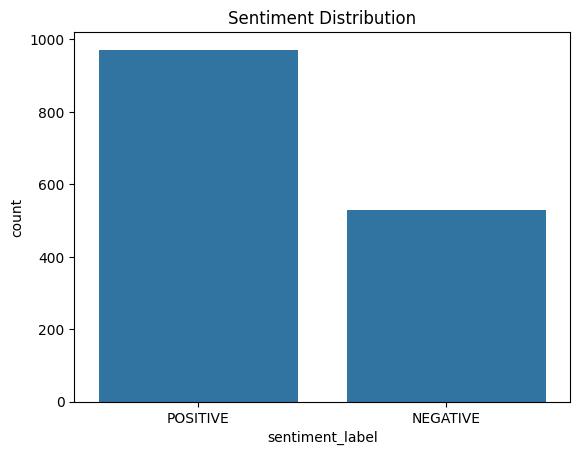

In [3]:
sns.countplot(
    data=df,
    x="sentiment_label"
)

plt.title("Sentiment Distribution")
plt.show()

In [ ]:
Sentiment by Bank

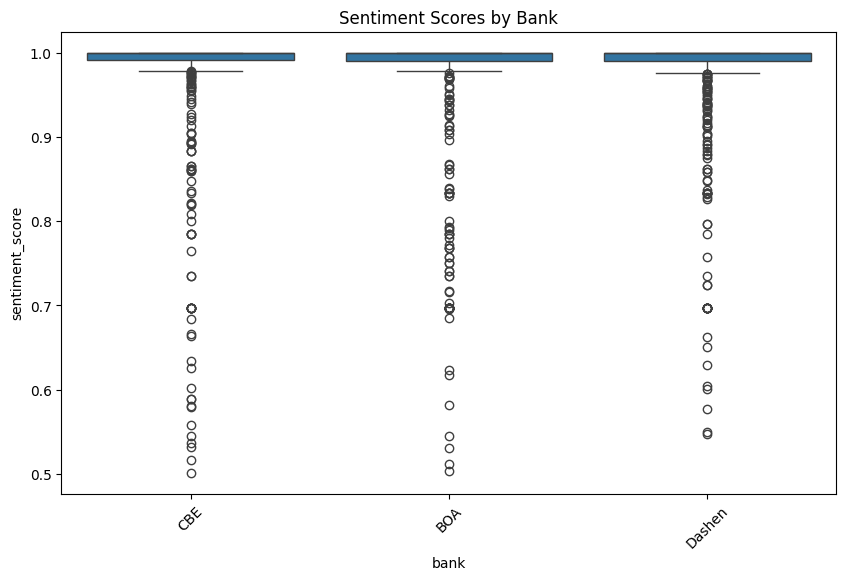

In [4]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="bank",
    y="sentiment_score"
)

plt.title("Sentiment Scores by Bank")
plt.xticks(rotation=45)

plt.show()

In [ ]:
Theme Distribution

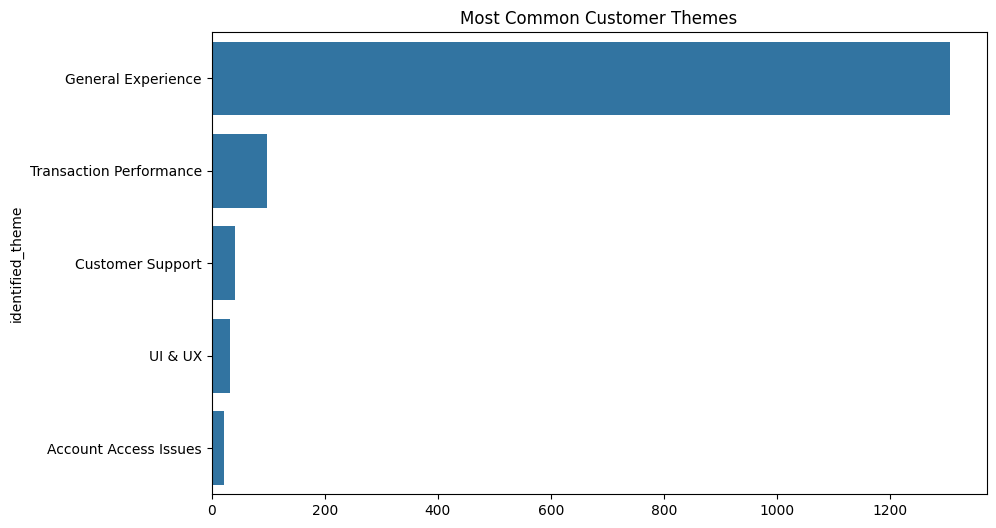

In [5]:
theme_counts = df["identified_theme"].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=theme_counts.values,
    y=theme_counts.index
)

plt.title("Most Common Customer Themes")

plt.show()

In [ ]:
Rating Distribution

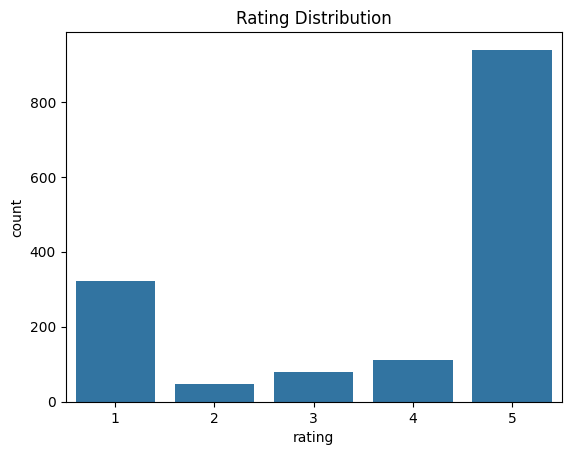

In [6]:
sns.countplot(
    data=df,
    x="rating"
)

plt.title("Rating Distribution")

plt.show()

Average Sentiment Per Bank

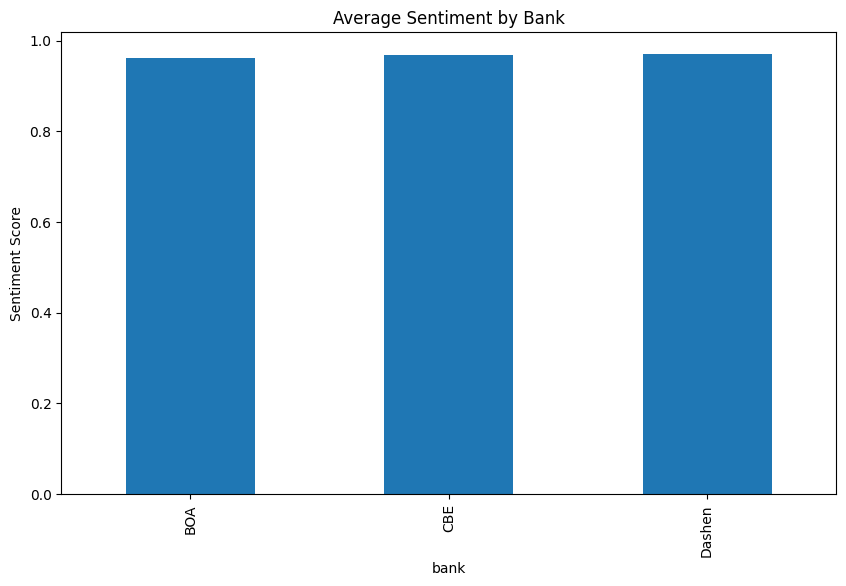

In [7]:
avg_sentiment = df.groupby("bank")["sentiment_score"].mean()

avg_sentiment.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Sentiment by Bank")
plt.ylabel("Sentiment Score")

plt.show()

Theme vs Sentiment

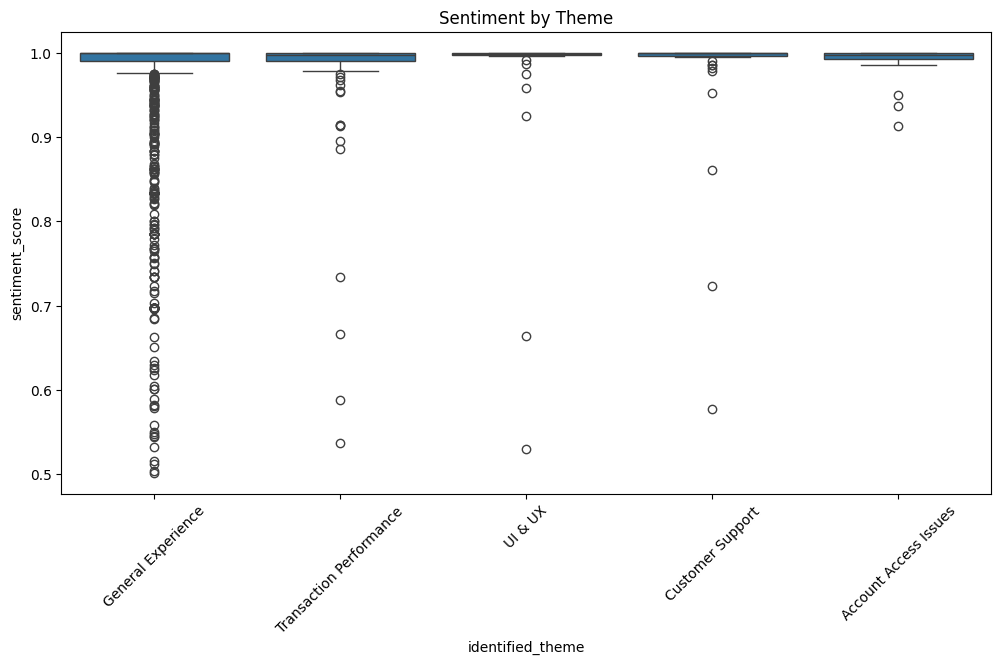

In [8]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="identified_theme",
    y="sentiment_score"
)

plt.xticks(rotation=45)

plt.title("Sentiment by Theme")

plt.show()

Generate Word Cloud

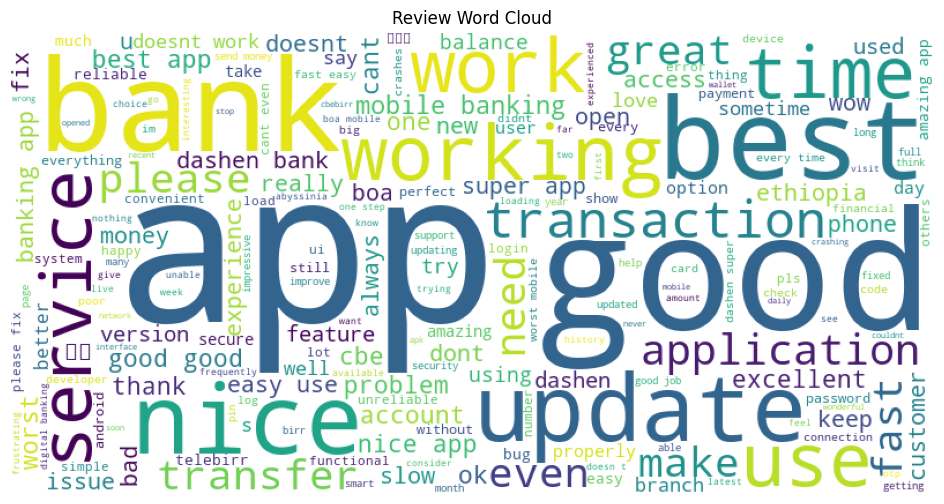

In [9]:
text = " ".join(df["clean_review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Review Word Cloud")

plt.show()

Back-Specific Word Clouds

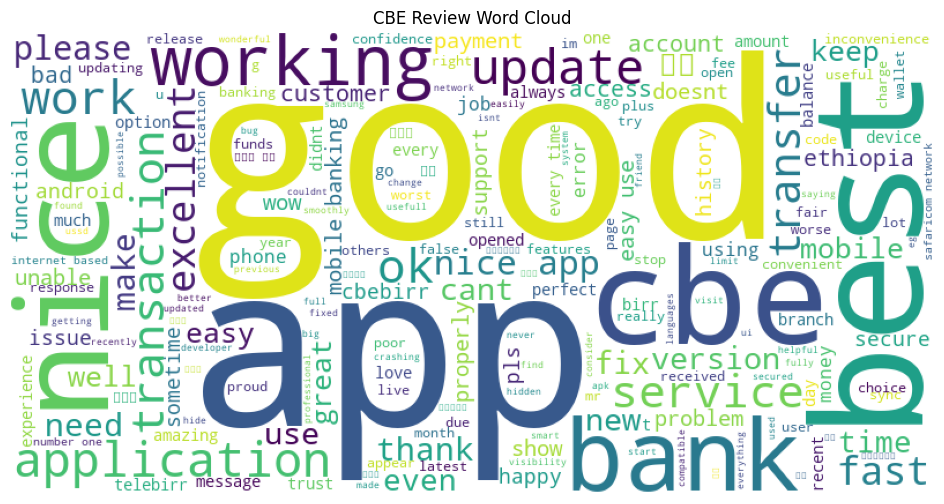

In [10]:
bank_reviews = df[df["bank"] == "CBE"]

text = " ".join(bank_reviews["clean_review"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("CBE Review Word Cloud")

plt.show()

Customer Sentiment
- Most reviews were positive overall.
- CBE showed the highest average sentiment score.

Major Customer Complaints
- Account access issues were the most frequent theme.
- Transaction delays strongly correlated with negative sentiment.

Product Feedback
- Users frequently requested biometric login improvements.
- UI/UX feedback was mostly positive.

In [11]:
plt.savefig("../reports/sentiment_distribution.png")

plt.show()

<Figure size 640x480 with 0 Axes>